## Hands-on - PCA

PCA is commonly used with high dimensional data.  One type of high dimensional data is images. In this example, we will work with a use case using images of numbers.

A classic example of working with image data is the MNIST dataset, which was open sourced in the late 1990s by researchers across Microsoft, Google, and NYU.  For more information:  http://yann.lecun.com/exdb/mnist/


In [24]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

The dataset has 42,000 images in the training dataset, and another 28,000 images in a test set.  Let's read in the datasets and see what they look like.  If you would like to follow along with me, you can open the workspace below this video in another window and work along with me.  Let's take a closer look at the data.

In [25]:
train = pd.read_csv("./data/train.csv")
train.fillna(0, inplace=True)

In [27]:
train.shape

(6304, 785)

In [28]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
train.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,6304.000000,6304.0,6304.0,6304.0,6304.0,6304.0,6304.0,6304.0,6304.0,6304.0,...,6304.000000,6304.000000,6304.000000,6304.0,6304.0,6304.0,6304.0,6304.0,6304.0,6304.0
mean,4.440355,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.139594,0.142291,0.026967,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,2.885613,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.099940,5.531089,1.675547,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,130.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


From a header and the describe of the data, we can see that the data has a label column with what digit was created, and the pixels for each part of the image are the features.  The values for the pixels are between 0 and 255.  For information about pixels -  https://homepages.inf.ed.ac.uk/rbf/HIPR2/value.htm

Given what we know about the data, let's split the label off and put the images in their own matrix.

In [30]:
# save the labels to a Pandas series target
y = train["label"]
# Drop the label feature
X = train.drop("label", axis=1)

/Users/amit/opt/anaconda3/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


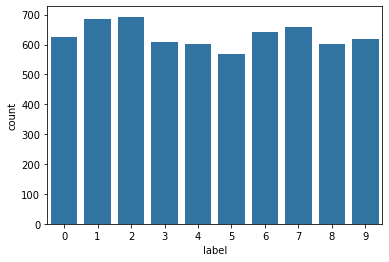

In [31]:
sns.countplot(
    y, color=sns.color_palette()[0]
);  # a very quick look at the data shows that all the labels appear roughly 4k times

Let's take a look at what a few of the numbers look like with this little function. This can be separately stored in helper function, and has nothing to do with PCA. It is just visualizing the images on each row.

In [32]:
def show_images(num_images):
    """
    This function plots the num_images provided of MNIST dataset.

    INPUT: num_images - int - The number of images you would like to view.
           Mod 10 of num_images should be 0 and it should be fewer than 101 images.
    OUTPUT: A figure with the images shown for the training data.
    """
    if num_images % 10 == 0 and num_images <= 100:
        for digit_num in range(0, num_images):
            plt.subplot(int(num_images / 10), 10, digit_num + 1)  # create subplots
            # mat_data = X.iloc[digit_num].as_matrix().reshape(28,28)  #reshape images
            mat_data = X.iloc[digit_num].to_numpy().reshape(28, 28)  # reshape images

            plt.imshow(mat_data)  # plot the data
            plt.xticks([])  # removes numbered labels on x-axis
            plt.yticks([])  # removes numbered labels on y-axis
    else:
        print(
            "That is not the right input, please read the docstring before continuing."
        )

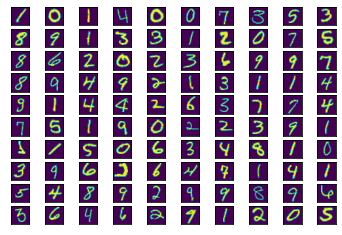

In [33]:
show_images(100)

Some of the numbers look pretty easy to identify, and others not so much. Here is another helper function to help us see each of the first 50 images for a input number.

In [34]:
def show_images_by_digit(digit_to_see):
    """
    This function plots the digits_to_see provided of MNIST dataset.

    INPUT: digits_to_see - int - A number between 0 and 9 of what you want to see.
    OUTPUT: A figure with the images shown for the training data.
    """
    if digit_to_see in list(range(10)):
        indices = np.where(y == digit_to_see)  # pull indices for num of interest
        for digit_num in range(0, 50):
            plt.subplot(5, 10, digit_num + 1)  # create subplots
            mat_data = (
                X.iloc[indices[0][digit_num]].to_numpy().reshape(28, 28)
            )  # reshape images
            plt.imshow(mat_data)  # plot the data
            plt.xticks([])  # removes numbered labels on x-axis
            plt.yticks([])  # removes numbered labels on y-axis
    else:
        print(
            "That is not the right input, please read the docstring before continuing."
        )

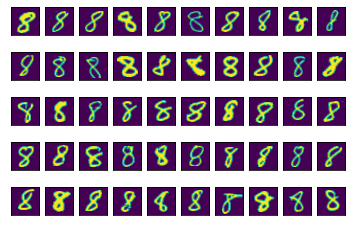

In [66]:
show_images_by_digit(8)

Some of these ones cannot be distinguished with eye, or are wrongly classified. One common way to use PCA is to reduce the dimensionality of high dimensionality data that you want to use for prediction, but the results seem to be overfitting (potentially because their is a lot of noise in the data.  Which can certainly be the case with image data).

Let's take a first pass on creating a simple model to predict the values of the images using all of the data.

[[203   0   0   0   0   0   5   0   1   0]
 [  0 234   3   0   0   0   1   2   3   0]
 [  2   5 211   1   3   0   1   4   0   1]
 [  3   0   6 173   0   5   0   1   1   2]
 [  1   0   1   0 171   0   2   0   0   3]
 [  2   1   0   3   0 174   4   1   1   0]
 [  3   1   1   0   1   2 202   1   0   0]
 [  0   1   7   1   6   0   0 203   1   6]
 [  1   1   0   6   2   3   0   0 187   2]
 [  2   1   0   2  12   1   0   0   4 186]]
AxesSubplot(0.125,0.125;0.62x0.755)
0.9341662662181643


0.9341662662181643

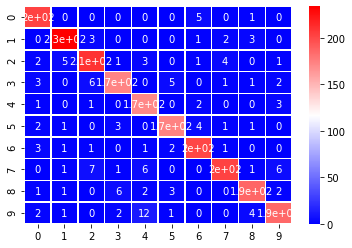

In [36]:
# Because we will fit this more than once, might as well make a function
def fit_random_forest_classifier(X, y):
    """
    INPUT: names are pretty self explanatory
    OUTPUT: none - prints the confusion matrix and accuracy
    """
    # First let's create training and testing data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.33, random_state=42
    )

    # We could grid search and tune, but let's just fit a simple model to see how it does
    # instantiate
    clf = RandomForestClassifier(n_estimators=100, max_depth=None)

    # fit
    clf.fit(X_train, y_train)

    # predict
    y_preds = clf.predict(X_test)

    # score
    mat = confusion_matrix(y_test, y_preds)
    print(mat)
    print(sns.heatmap(mat, annot=True, cmap="bwr", linewidths=0.5))
    acc = accuracy_score(y_test, y_preds)
    print(acc)
    return acc


fit_random_forest_classifier(X, y)

On the confusion matrix, anything along the diagonal, is something where we predicted the same values that was actually true. And any of the values that are off diagonal are something where we predicted values that was not true. Here you can see that the dark blue indicates that there are very few images that were mislabeled. Elements along the diagonal indicates high number associated with the values being correctly predicted.

The above model does pretty well on the test set using all of the data, let's see how well a model can do with a much lower number of features.  Perhaps, we can do as well or better by reducing the noise in the original features.

Note - Working with unsupervised techniques in scikit learn follows a similar process as working with supervised techniques, but excludes predicting and scoring, and instead we just need to transform our data.  Often the fit and transform are done all in one step.

1. Instantiate your model (with the hyperparameters values)
2. Fit the model to the training data.
3. Predict using the fitted model on the test data
4. Score your model - comparing the actual values to the test data.

**You can also try a grid search to see if you can improve your initial predictions.**

It is worth mentioning that because all of our features are on the same scale from 0 to 255, scaling isn't super necessary here. Without standardizing, this process would only work for data that was already scaled.

You can use the below function to perform PCA on this dataset, but also any other dataset. The function takes certain number of components from your datasets, it fits your PCA and then gives you back the X Matrix with that reduced number of features as well as the PCA model that you fit. 

In [37]:
def do_pca(n_components, data):
    """
    Transforms data using PCA to create n_components, and provides back the results of the
    transformation.

    INPUT: n_components - int - the number of principal components to create
           data - the data you would like to transform

    OUTPUT: pca - the pca object created after fitting the data
            X_pca - the transformed X matrix with new number of components
    """
    X = StandardScaler().fit_transform(data)
    pca = PCA(n_components)
    X_pca = pca.fit_transform(X)
    return pca, X_pca

In [67]:
# To start create PCA model with 2 components
pca, X_pca = do_pca(26, X)

In [68]:
X_pca.shape

(6304, 26)

In [69]:
X.shape

(6304, 784)

In [44]:
X.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [70]:
X_pca

array([[-4.99547951e+00, -5.87609464e+00,  2.41072361e+00, ...,
         7.31918612e-01,  2.19161407e+00,  1.37335659e+00],
       [ 1.91585183e+01,  6.30631505e+00,  1.94455708e+00, ...,
         1.56114516e+00, -1.38777724e-02, -2.32158931e+00],
       [-7.55158697e+00, -2.22519933e+00,  1.88175901e+00, ...,
        -3.84390336e-01, -1.79782621e+00,  7.80217779e-01],
       ...,
       [-7.94002485e+00,  3.48696351e+00, -4.72194019e+00, ...,
        -1.60506905e+00,  1.34415720e+00, -1.85957233e+00],
       [ 1.89557968e+01,  1.12820772e+00, -5.95580289e+00, ...,
         1.31894134e+00,  1.84004899e+00,  7.11162670e-01],
       [-1.47927108e+00,  3.79810003e+00,  1.77260560e+01, ...,
         2.88726699e+00,  6.54952956e-01,  5.84301960e+00]])

[[192   0   4   0   0   1   9   1   1   1]
 [  0 234   2   0   0   0   2   0   4   1]
 [  2   2 208   4   3   0   2   3   4   0]
 [  0   0   9 168   0   5   1   2   5   1]
 [  0   0   5   0 155   1   5   1   0  11]
 [  2   0   2   6   1 167   0   0   5   3]
 [  3   0   1   0   3   2 201   0   1   0]
 [  0   0   6   3   4   0   0 198   2  12]
 [  0   2   1  14   0   8   0   0 174   3]
 [  2   0   2   3  15   1   0  12   1 172]]
AxesSubplot(0.125,0.125;0.62x0.755)
0.8981259010091303


0.8981259010091303

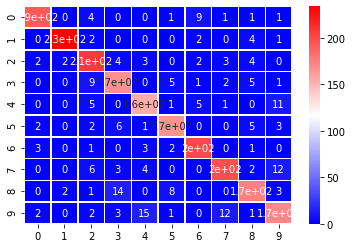

In [71]:
fit_random_forest_classifier(X_pca, y)

Clearly two components isn't giving us enough information to clearly identify the digits.  Let's consider a few more components, and take a closer look at what we know about the components.

In [47]:
pca.components_.shape

(2, 784)

In [73]:
pca.components_.shape

(26, 784)

In [49]:
pca.components_

array([[ 1.32861446e-18,  6.72424271e-19, -3.87531283e-19, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 8.62588072e-18,  2.46007581e-17, -9.94494681e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In order to better see how the components are separating out the handwritten digits, let us write another code that would help us to visualize that.

In [52]:
def plot_components(X, y):
    """
    plots the data in a 2 dimensional space to view separation
    INPUT: pretty straightforward again
    OUTPUT: none
    """
    x_min, x_max = np.min(X, 0), np.max(X, 0)
    X = (X - x_min) / (x_max - x_min)
    plt.figure(figsize=(10, 6))
    for i in range(X.shape[0]):
        plt.text(
            X[i, 0], X[i, 1], str(y[i]), color=plt.cm.Set1(y[i]), fontdict={"size": 15}
        )

    plt.xticks([]), plt.yticks([]), plt.ylim([-0.1, 1.1]), plt.xlim([-0.1, 1.1])

Ideally we should be plotting all the values, but the plot could be very crowded. So we just take the first 100.

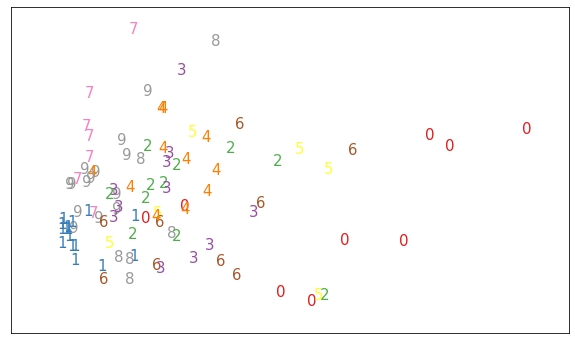

In [53]:
plot_components(X_pca[:100], y[:100])  # 2 components

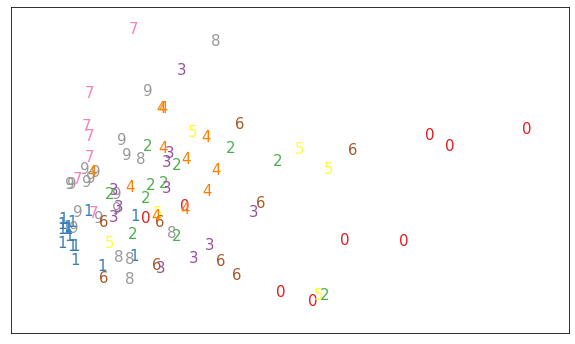

In [74]:
plot_components(X_pca[:100], y[:100])  # 26 components

In [55]:
pca.explained_variance_ratio_

array([0.06135278, 0.04292222, 0.04122265, 0.03205943, 0.02736555,
       0.02425957, 0.02019702, 0.01905798, 0.01699841, 0.01529554,
       0.0146957 , 0.01298059, 0.01238759, 0.01202146, 0.0114382 ,
       0.01109688, 0.01024638, 0.01013547, 0.00996201, 0.0094907 ,
       0.00939982, 0.00880685, 0.00856467, 0.00826962, 0.00812396])

[[114   0  36   9   6  12  25   0   7   0]
 [  0 207   0   4   2   6   4   5   9   6]
 [ 36   2  72  30  14  20  35   1  15   3]
 [ 12   2  32  20  24  26  23  11  28  13]
 [  6   4  20  20  50  14  14  10  13  27]
 [  9   8  30  22  18  25  27   4  33  10]
 [ 30   6  48  22  11  29  35   3  25   2]
 [  4   4   3  10  35   9   2  95   8  55]
 [  6   6  28  28  23  29  24  10  40   8]
 [  2  12   4  17  31  10   4  59   7  62]]
AxesSubplot(0.125,0.125;0.62x0.755)
0.3459875060067275
[[156   0   7   1   2  11  20   1  11   0]
 [  0 222   1   2   2   5   9   0   2   0]
 [ 18   3 122  31   5   3  38   0   7   1]
 [  3   3  53  61   6  13  29   4  16   3]
 [  6   0   3   3  96  16   1  14  11  28]
 [  9   0  11  14  23  59  27   6  32   5]
 [ 18   7  15  16   2  11 131   0  11   0]
 [  1   2   0   2  28   6   1 119   8  58]
 [ 16   5   7  28  28  34  34   0  48   2]
 [  2   2   1   2  47   3   1  50   9  91]]
AxesSubplot(0.125,0.125;0.496x0.755)
0.5309947140797694
[[176   0   8   0   4  10  

AxesSubplot(0.125,0.125;0.0174514x0.755)
0.897164824603556
[[191   0   2   1   0   4   7   2   1   1]
 [  0 233   2   0   0   0   2   0   5   1]
 [  1   2 209   5   1   0   2   3   4   1]
 [  0   0   8 165   0   7   0   2   7   2]
 [  0   0   3   0 158   1   5   1   0  10]
 [  2   0   4   7   2 163   2   0   3   3]
 [  5   0   1   0   3   1 200   0   1   0]
 [  0   1   6   1   3   0   1 197   3  13]
 [  1   2   1  12   1   8   1   0 174   2]
 [  2   0   1   3  15   0   0  16   1 170]]
AxesSubplot(0.125,0.125;0.0139612x0.755)
0.8938010571840461
[[191   0   3   1   0   2   8   1   1   2]
 [  0 234   2   0   0   0   2   0   4   1]
 [  2   2 207   5   3   1   2   3   3   0]
 [  0   0   8 167   0   6   0   2   6   2]
 [  0   0   5   0 152   2   4   1   0  14]
 [  3   0   2   8   1 165   1   0   3   3]
 [  2   0   1   0   4   1 202   0   1   0]
 [  0   1   6   1   4   0   0 200   2  11]
 [  2   2   0  14   1   8   1   0 173   1]
 [  1   0   2   4  17   0   0  18   1 165]]
AxesSubplot(0.125,0

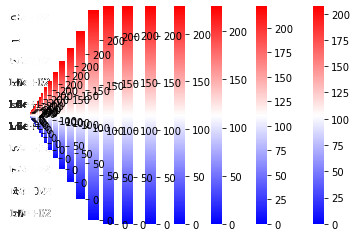

In [54]:
for comp in range(2, 100):
    pca, X_pca = do_pca(comp, X)
    acc = fit_random_forest_classifier(X_pca, y)
    if acc > 0.90:
        print(
            "With only {} components, a random forest acheived an accuracy of {}.".format(
                comp, acc
            )
        )
        break

[[109   0  42   9   6   7  27   0   9   0]
 [  0 210   0   4   1   6   4   5   9   4]
 [ 36   2  66  31  16  25  34   0  14   4]
 [ 10   2  31  21  20  27  26  11  29  14]
 [  5   5  16  21  48  13  19  13  13  25]
 [  7   8  32  24  15  23  29   4  34  10]
 [ 31   5  52  19  10  30  33   3  26   2]
 [  3   3   5  10  30   9   2  90  10  63]
 [  5   6  29  30  21  35  23   9  36   8]
 [  2  12   4  15  30  10   4  55  12  64]]
AxesSubplot(0.125,0.125;0.62x0.755)
0.3363767419509851
[[157   0   7   5   1   7  23   1   8   0]
 [  0 224   1   3   2   2   7   0   4   0]
 [ 18   3 125  31   5   4  34   0   7   1]
 [  3   3  56  59   5  14  25   4  18   4]
 [  7   0   3   5  97  11   2  16  11  26]
 [  9   0   9  17  22  58  24   8  31   8]
 [ 16   7  15  18   2  11 128   0  14   0]
 [  0   2   0   6  24   8   1 119   6  59]
 [ 13   4   8  29  29  32  33   1  51   2]
 [  2   2   1   2  49   4   1  56   7  84]]
AxesSubplot(0.125,0.125;0.496x0.755)
0.5295530994714079
[[176   0   8   0   4  10  

AxesSubplot(0.125,0.125;0.0174514x0.755)
0.8885151369533878
[[192   0   3   0   0   4   8   1   1   0]
 [  0 234   2   0   0   1   2   0   4   0]
 [  2   2 205   7   1   0   3   3   4   1]
 [  0   0   7 165   0   6   1   2   7   3]
 [  0   0   3   0 153   1   5   1   0  15]
 [  1   0   1   8   2 164   2   0   4   4]
 [  4   0   1   0   4   1 200   0   1   0]
 [  0   0   4   5   5   0   0 194   1  16]
 [  0   2   3  11   1   8   1   0 174   2]
 [  2   0   2   3  15   1   0  16   1 168]]
AxesSubplot(0.125,0.125;0.0139612x0.755)
0.8885151369533878
[[195   0   3   0   0   0   8   1   1   1]
 [  0 234   2   1   0   1   2   0   3   0]
 [  2   2 209   4   3   0   2   4   2   0]
 [  0   0   8 168   0   6   0   1   6   2]
 [  0   0   3   0 156   1   5   1   0  12]
 [  2   0   2   7   1 165   3   0   3   3]
 [  5   0   2   0   1   1 201   1   0   0]
 [  0   0   6   1   4   0   1 195   3  15]
 [  1   2   1  12   0   9   0   0 175   2]
 [  3   0   1   3  17   0   0  14   1 169]]
AxesSubplot(0.125,

AxesSubplot(0.125,0.125;0.000392972x0.755)
0.9005285920230658
[[195   0   2   1   0   1   7   1   1   1]
 [  0 234   2   0   0   0   2   0   4   1]
 [  1   2 207   6   2   0   3   4   3   0]
 [  0   0   8 171   0   5   0   2   5   0]
 [  0   0   5   0 157   0   5   2   0   9]
 [  1   0   3   9   2 166   2   0   1   2]
 [  4   0   2   0   4   0 200   0   1   0]
 [  0   0   7   2   3   0   1 200   2  10]
 [  2   2   1  12   2   7   1   0 173   2]
 [  1   0   1   2  18   2   0  12   3 169]]
AxesSubplot(0.125,0.125;0.000314377x0.755)
0.8995675156174916
[[193   0   4   1   0   2   7   1   0   1]
 [  0 233   2   0   0   0   2   0   5   1]
 [  3   3 207   4   2   0   2   4   3   0]
 [  0   0   9 171   0   5   0   2   4   0]
 [  0   0   5   0 157   1   4   0   0  11]
 [  0   0   0   7   2 168   2   0   2   5]
 [  3   0   2   0   4   1 200   0   1   0]
 [  0   1   6   2   3   0   0 204   0   9]
 [  3   2   0   9   0   6   1   0 178   3]
 [  1   0   2   3  16   0   0  13   1 172]]
AxesSubplot(0.

AxesSubplot(0.125,0.125;8.84894e-06x0.755)
0.9048534358481499
[[196   0   2   1   1   1   7   1   0   0]
 [  0 232   2   1   0   0   2   0   5   1]
 [  2   2 205   4   2   2   4   3   3   1]
 [  0   0   8 170   0   4   0   2   7   0]
 [  1   0   5   0 155   1   2   1   0  13]
 [  0   0   1   9   0 169   0   0   4   3]
 [  5   0   2   0   2   1 201   0   0   0]
 [  1   1   8   2   4   0   0 189   2  18]
 [  1   2   1  11   2   6   0   0 178   1]
 [  1   0   1   3  11   1   0  15   0 176]]
AxesSubplot(0.125,0.125;7.07915e-06x0.755)
0.8990869774147044
[[195   0   4   0   0   0   8   1   1   0]
 [  0 233   2   0   0   0   2   0   5   1]
 [  3   2 207   5   2   0   2   3   3   1]
 [  1   0  11 166   0   5   0   2   5   1]
 [  0   0   5   0 155   0   4   0   0  14]
 [  1   0   3   6   1 168   1   1   2   3]
 [  6   0   2   0   2   2 198   0   1   0]
 [  0   0   6   2   6   0   0 199   0  12]
 [  0   1   1  12   1   7   0   0 177   3]
 [  1   0   2   2  11   0   0  14   0 178]]
AxesSubplot(0.

AxesSubplot(0.125,0.125;1.9926e-07x0.755)
0.8981259010091303
[[196   0   4   1   0   0   6   1   1   0]
 [  0 233   2   0   0   1   2   0   4   1]
 [  2   2 207   5   1   0   4   2   3   2]
 [  0   0   7 169   0   7   0   2   6   0]
 [  0   0   6   0 156   1   3   2   0  10]
 [  0   0   2   8   1 167   1   1   2   4]
 [  3   0   3   0   2   3 200   0   0   0]
 [  1   0   8   2   4   0   0 202   1   7]
 [  2   2   2   8   2  12   1   0 173   0]
 [  1   0   2   2  11   0   0  16   1 175]]
AxesSubplot(0.125,0.125;1.59408e-07x0.755)
0.9024507448342143
[[195   0   2   1   1   1   8   1   0   0]
 [  0 233   3   0   0   1   2   0   3   1]
 [  3   3 209   3   2   0   1   4   3   0]
 [  0   0  10 168   0   5   0   3   5   0]
 [  0   0   5   0 153   1   4   2   0  13]
 [  1   0   0  11   0 164   2   1   4   3]
 [  3   0   1   0   1   5 201   0   0   0]
 [  0   0   8   1   2   0   1 203   2   8]
 [  3   1   1  10   3  10   0   0 172   2]
 [  2   0   3   2  12   0   0  14   0 175]]
AxesSubplot(0.1

AxesSubplot(0.125,0.125;4.48694e-09x0.755)
0.9082172032676598
[[193   0   5   0   0   0  10   1   0   0]
 [  0 234   3   0   0   1   2   0   2   1]
 [  2   2 207   6   2   0   3   3   2   1]
 [  0   0  10 168   0   3   1   2   6   1]
 [  0   0   4   0 157   0   6   1   0  10]
 [  0   0   3   5   0 170   2   0   3   3]
 [  4   0   1   0   1   2 202   0   1   0]
 [  0   0   9   2   3   0   0 198   1  12]
 [  3   1   1   9   2  12   1   1 171   1]
 [  1   0   2   2  13   0   0  17   4 169]]
AxesSubplot(0.125,0.125;3.58955e-09x0.755)
0.8981259010091303
[[195   0   3   0   1   1   6   2   1   0]
 [  0 233   2   1   0   1   2   0   3   1]
 [  1   2 209   3   2   0   5   3   3   0]
 [  0   0   7 171   0   5   1   3   4   0]
 [  0   0   6   0 156   0   5   1   0  10]
 [  2   0   2   7   1 166   2   0   3   3]
 [  4   0   2   0   0   3 202   0   0   0]
 [  0   0   7   3   2   0   0 201   2  10]
 [  2   2   1  12   2  16   0   0 164   3]
 [  1   0   1   3  15   0   0  18   3 167]]
AxesSubplot(0.

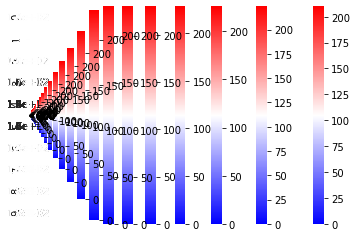

In [56]:
# I would highly recommend not running the below code, as it had to run overnight to complete.
# Instead, you can run a smaller number of components that still allows you to see enough.


accs = []
comps = []
# for comp in range(2, 700):
for comp in range(2, 100):
    comps.append(comp)
    pca, X_pca = do_pca(comp, X)
    acc = fit_random_forest_classifier(X_pca, y)
    accs.append(acc)

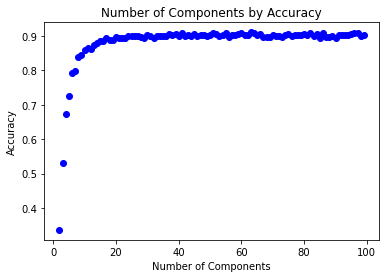

In [57]:
plt.plot(comps, accs, "bo")
plt.xlabel("Number of Components")
plt.ylabel("Accuracy")
plt.title("Number of Components by Accuracy");

In [58]:
# The max accuracy and corresponding number of components
np.max(accs), comps[np.where(accs == np.max(accs))[0][0]]

(0.9106198942815954, 63)

Here you can see that the accuracy quickly levels off. The maximum accuracy is actually acheived at 63 principal components. Given the slight negative trend also indicates that the final components are mostly containing noise. The 64 components here contain the information needed to be able to determine the images nearly to the same ability as using the entire image. Next, let's take a closer look at exactly what other information we get from PCA, and how we can interpret it.

In [59]:
def scree_plot(pca):
    """
    Creates a scree plot associated with the principal components

    INPUT: pca - the result of instantian of PCA in scikit learn

    OUTPUT:
            None
    """
    num_components = len(pca.explained_variance_ratio_)
    ind = np.arange(num_components)
    vals = pca.explained_variance_ratio_

    plt.figure(figsize=(10, 6))
    ax = plt.subplot(111)
    cumvals = np.cumsum(vals)
    ax.bar(ind, vals)
    ax.plot(ind, cumvals)
    for i in range(num_components):
        ax.annotate(
            r"%s%%" % ((str(vals[i] * 100)[:4])),
            (ind[i] + 0.2, vals[i]),
            va="bottom",
            ha="center",
            fontsize=12,
        )

    ax.xaxis.set_tick_params(width=0)
    ax.yaxis.set_tick_params(width=2, length=12)

    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance Explained (%)")
    plt.title("Explained Variance Per Principal Component")

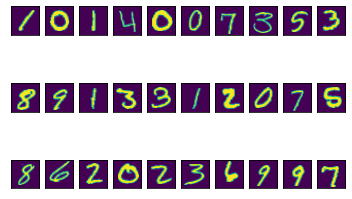

In [60]:
show_images(30)

In [61]:
pca, X_pca = do_pca(10, X)

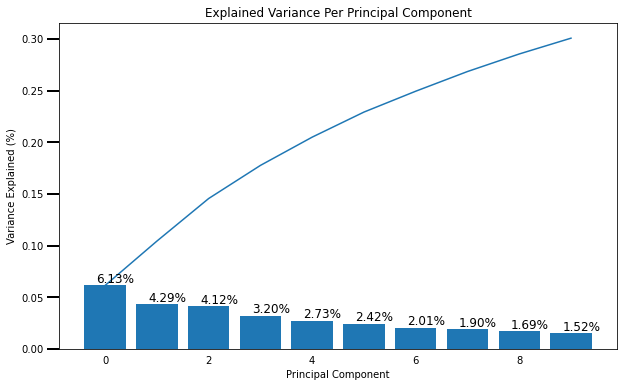

In [62]:
scree_plot(pca)

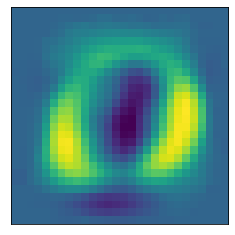

In [63]:
def plot_component(pca, comp):
    """
    Plots an image associated with each component to understand how the weighting
    of the components
    INPUT:
          pca - pca object created from PCA in sklearn
          comp - int - the component you want to see starting at 0
    OUTPUT
          None
    """
    if comp <= len(pca.components_):
        mat_data = np.asmatrix(pca.components_[comp]).reshape(28, 28)  # reshape images
        plt.imshow(mat_data)
        # plot the data
        plt.xticks([])  # removes numbered labels on x-axis
        plt.yticks([])  # removes numbered labels on y-axis
    else:
        print(
            "That is not the right input, please read the docstring before continuing."
        )


# Plot the first component
plot_component(pca, 0)

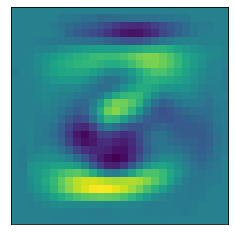

In [64]:
plot_component(pca, 3)

From this notebook, you have had an opportunity to look at the two major parts of PCA:

I. The amount of variance explained by each component. This is called an eigenvalue.

II. The principal components themselves, each component is a vector of weights. In this case, the principal components help us understand which pixels of the image are most helpful in identifying the difference between between digits. Principal components are also known as eigenvectors.